Dataset Loaded. Sample data:
                 date       co     no     no2     o3    so2   pm2_5    pm10  \
0 2020-11-25 01:00:00  2616.88   2.18   70.60  13.59  38.62  364.61  411.73   
1 2020-11-25 02:00:00  3631.59  23.25   89.11   0.33  54.36  420.96  486.21   
2 2020-11-25 03:00:00  4539.49  52.75  100.08   1.11  68.67  463.68  541.95   
3 2020-11-25 04:00:00  4539.49  50.96  111.04   6.44  78.20  454.81  534.00   
4 2020-11-25 05:00:00  4379.27  42.92  117.90  17.17  87.74  448.14  529.19   

     nh3  
0  28.63  
1  41.04  
2  49.14  
3  48.13  
4  46.61  

Labeled dataset size: (7228, 10)
Source
Industrial    3833
Accident      1437
Traffic       1058
Dust           900
Name: count, dtype: int64

Classification Report:

              precision    recall  f1-score   support

    Accident       0.99      1.00      1.00       287
        Dust       1.00      0.99      0.99       180
  Industrial       1.00      1.00      1.00       767
     Traffic       1.00      1.00      1.00  

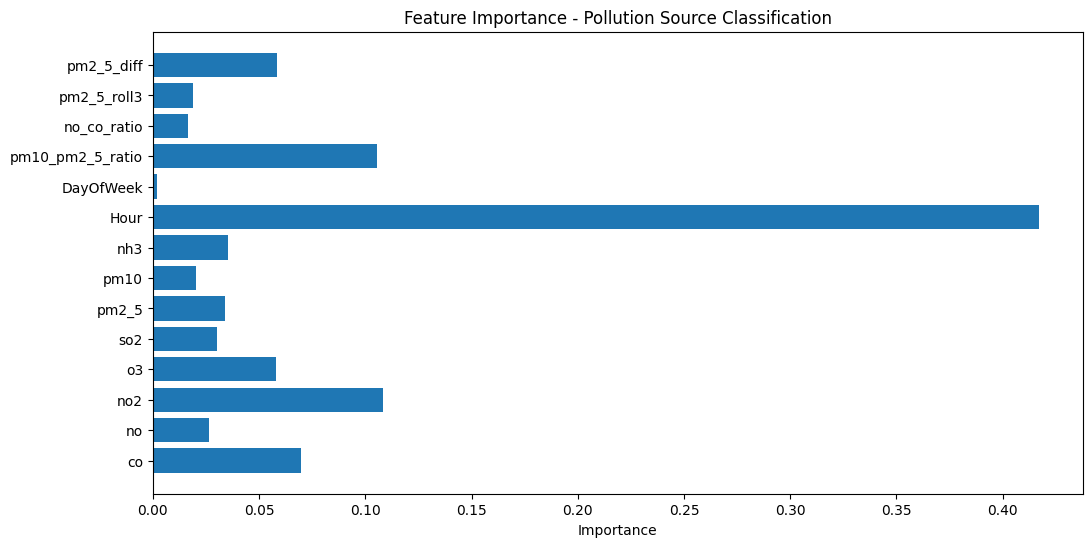


Model saved as rf_pollution_source.pkl


In [ ]:
# pollution_source_classification.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import joblib

# ----------------------------
# 1. Load Dataset
# ----------------------------
df = pd.read_csv('delhi_aqi.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')
df.reset_index(drop=True, inplace=True)

print("Dataset Loaded. Sample data:")
print(df.head())

# ----------------------------
# 2. Label Pollution Sources
# ----------------------------

def label_source(row, df):
    """
    Rule-based labeling:
    Traffic: high NO & CO during rush hours
    Industrial: high SO2 at night
    Dust: PM10 much higher than PM2.5
    Accident: sudden PM2.5 spike
    """
    # Traffic: rush hours + high NO/CO
    if ((7 <= row['date'].hour <= 10) or (17 <= row['date'].hour <= 20)) and row['no'] > 40 and row['co'] > 2:
        return 'Traffic'
    # Industrial: SO2 high at night
    elif (0 <= row['date'].hour <= 4) and row['so2'] > 20:
        return 'Industrial'
    # Dust: PM10 >> PM2.5
    elif row['pm10'] > 2 * row['pm2_5']:
        return 'Dust'
    # Accident/fire: sudden spike
    elif row['pm2_5'] > df['pm2_5'].rolling(3).mean().iloc[row.name] + 50:
        return 'Accident'
    else:
        return 'Other'

df['Source'] = df.apply(lambda row: label_source(row, df), axis=1)

# Remove unlabeled rows
df = df[df['Source'] != 'Other'].reset_index(drop=True)
print(f"\nLabeled dataset size: {df.shape}")
print(df['Source'].value_counts())

# ----------------------------
# 3. Feature Engineering
# ----------------------------

# Time features
df['Hour'] = df['date'].dt.hour
df['DayOfWeek'] = df['date'].dt.dayofweek

# Pollutant ratios
df['pm10_pm2_5_ratio'] = df['pm10'] / df['pm2_5']
df['no_co_ratio'] = df['no'] / df['co']

# Rolling and difference features
df['pm2_5_roll3'] = df['pm2_5'].rolling(3).mean()
df['pm2_5_diff'] = df['pm2_5'].diff()

# Drop NaNs created by rolling/diff
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# ----------------------------
# 4. Train-Test Split
# ----------------------------

features = ['co','no','no2','o3','so2','pm2_5','pm10','nh3',
            'Hour','DayOfWeek','pm10_pm2_5_ratio','no_co_ratio','pm2_5_roll3','pm2_5_diff']

X = df[features]
y = df['Source']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ----------------------------
# 5. Train Random Forest Classifier
# ----------------------------
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# ----------------------------
# 6. Evaluation
# ----------------------------
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Feature Importance
importances = rf.feature_importances_
plt.figure(figsize=(12,6))
plt.barh(features, importances)
plt.xlabel("Importance")
plt.title("Feature Importance - Pollution Source Classification")
plt.show()

# ----------------------------
# 7. Save Model
# ----------------------------
joblib.dump(rf, 'rf_pollution_source.pkl')
print("\nModel saved as rf_pollution_source.pkl")
